# Simple diffusion

In [275]:
import os
import numpy as np
from matplotlib import pyplot as plt
from functools import partial

import torch
import torch.nn as nn
import torch.optim as optim
from torchsummary import summary

import diffusion as diff
import helper as dl

In [276]:
# If the kernel is not restarted, packages are not reloaded by default
# This is to make sure the changes in the python scripts are loaded
import importlib

importlib.reload(diff)
importlib.reload(dl);

### File paths and flags

In [277]:
DATA_PATH = "../datasets/mnist"
PLOT_PATH = "/mnt/Datos/LaTeX/deep-learning/ex6/figures"
MODEL_PATH = "models"

if not os.path.exists(DATA_PATH):
    raise Exception("Data folder does not exist")
if not os.path.exists(PLOT_PATH):
    raise Exception("Plots folder does not exist")
if not os.path.exists(MODEL_PATH):
    raise Exception("Model folder does not exist")

In [278]:
# Flags
TRAIN = True # Set to False to load a pre-trained model and skip training
SAVE_MODEL = False
SAVE_PLOTS = False

# Model name
SAVE_MODEL_NAME = "simple-diffusion.pth"
LOAD_MODEL_NAME = "simple-diffusion1.pth"

if not SAVE_PLOTS:
    PLOT_PATH = None

### Hyperparameter selection

In [279]:
# General hyperparameters
learning_rate = 0.8e-4
batch_size = 64
num_epochs = 300
patience = None

# Model hyperparameters. We use a dictionary to save them together with the model
time_steps = 250
beta = torch.tensor(0.02)
model_hyperparams = {
        'hidden_dims': [64, 64, 64],
    }

### Loading data

In [280]:
# Load the data
train_dataset, val_dataset, pdf = diff.get_simple_data(train_samples=10000, val_samples=1000)

In [281]:
# Create data loaders
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

**Normalizar datos y tiempos!!!!**

### Definition of the model

In [282]:
# Define the discriminator model
class MLP(nn.Module):
    def __init__(self, hidden_dims):
        super().__init__()
        
        layers = []
        input_dim = 2
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(input_dim, hidden_dim))
            layers.append(nn.ReLU())
            input_dim = hidden_dim
        layers.append(nn.Linear(input_dim, 1))
        self.linear = nn.Sequential(*layers)

    def forward(self, x):
        return self.linear(x)

In [283]:
# Define the loss function. We take the random t and noise as inputs
def diffusion_loss(inputs, model, beta, t, noise):
    alpha_t = (1 - beta) ** (t + 1)

    noisy_sample = torch.sqrt(alpha_t) * inputs + torch.sqrt(1-alpha_t) * noise
    model_input = torch.stack((noisy_sample, t), dim=1)

    noise_pred = model(model_input).squeeze()
    # Be careful with the shapes of the tensors
    # It was not working because the output of the model had shape (batch_size, 1) and noise had shape (batch_size)
    loss = nn.MSELoss()(noise_pred, noise)
    
    return loss

### Training the neural network

In [284]:
# Choose the best device
device = dl.get_device()
print(f"Using device: {device}")

Using device: xpu


In [285]:
if TRAIN:
    model = MLP(**model_hyperparams).to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    loss_fn = diffusion_loss

    print(f'Learning rate: {learning_rate}\n')
    summary(model);

Learning rate: 8e-05

Layer (type:depth-idx)                   Param #
├─Sequential: 1-1                        --
|    └─Linear: 2-1                       192
|    └─ReLU: 2-2                         --
|    └─Linear: 2-3                       4,160
|    └─ReLU: 2-4                         --
|    └─Linear: 2-5                       4,160
|    └─ReLU: 2-6                         --
|    └─Linear: 2-7                       65
Total params: 8,577
Trainable params: 8,577
Non-trainable params: 0


In [286]:
if TRAIN:
    # Train the model
    train_losses,val_losses = diff.train_diffusion_model(train_loader, val_loader, model, time_steps, beta, loss_fn, optimizer,
                num_epochs=num_epochs, patience=patience, device=device)

Training diffusion model on xpu.
Epoch [1/300], Step [10/157] -> Loss: 0.9728

Epoch [1/300] -> Train Loss: 0.9654, Val Loss: 0.9192, Time: 0.65 seconds
Epoch [2/300] -> Train Loss: 0.9097, Val Loss: 0.9118, Time: 0.58 seconds
Epoch [3/300] -> Train Loss: 0.8583, Val Loss: 0.8017, Time: 0.72 seconds
Epoch [4/300] -> Train Loss: 0.7990, Val Loss: 0.8035, Time: 0.54 seconds
Epoch [5/300] -> Train Loss: 0.7723, Val Loss: 0.7692, Time: 0.68 seconds
Epoch [6/300] -> Train Loss: 0.7308, Val Loss: 0.7070, Time: 0.66 seconds
Epoch [7/300] -> Train Loss: 0.7499, Val Loss: 0.7075, Time: 0.50 seconds
Epoch [8/300] -> Train Loss: 0.7307, Val Loss: 0.6851, Time: 0.53 seconds
Epoch [9/300] -> Train Loss: 0.7161, Val Loss: 0.7691, Time: 0.60 seconds
Epoch [10/300] -> Train Loss: 0.6887, Val Loss: 0.6528, Time: 0.56 seconds
Epoch [11/300] -> Train Loss: 0.6715, Val Loss: 0.6064, Time: 0.60 seconds
Epoch [12/300] -> Train Loss: 0.6484, Val Loss: 0.6064, Time: 0.52 seconds
Epoch [13/300] -> Train Loss: 0.6570, Val Loss: 0.6736, Time: 0.51 seconds
Epoch [14/300] -> Train Loss: 0.64

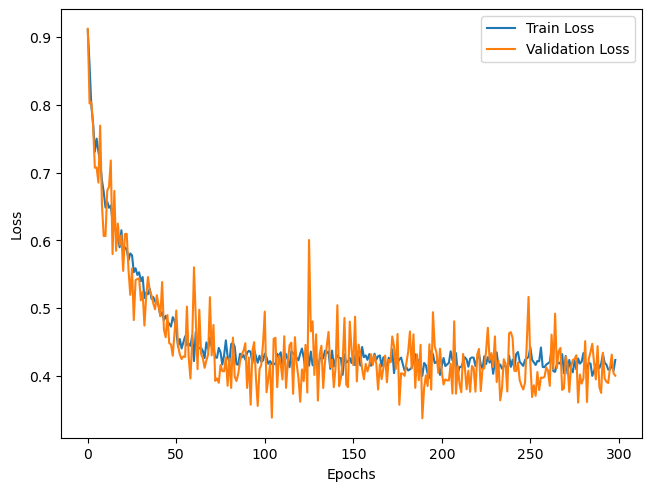

In [287]:
# Plot training/validation loss
if TRAIN:
    dl.plot_losses(train_losses, val_losses, PATH=PLOT_PATH)

### Evaluating the model

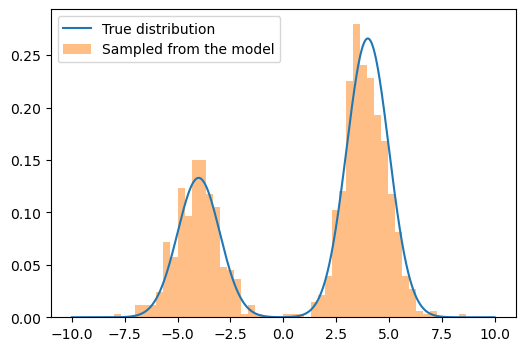

In [288]:
sample = diff.sample_diffusion_model(model, time_steps, beta, n_samples=1000, device=device)

plt.figure(figsize=(6, 4))
x = np.linspace(-10, 10, 1000)
plt.plot(x, pdf(x), label='True distribution')
plt.hist(sample, bins=50, density=True, alpha=0.5, label='Sampled from the model')
plt.legend()
plt.show()